Позиция  1: G(97.3%), E(1.1%), A(0.5%)
Позиция  2: F(97.6%), L(1.1%), I(0.6%)
Позиция  3: T(82.7%), S(6.6%), I(3.3%)
Позиция  4: F(96.0%), L(2.9%), I(0.5%)
Позиция  5: S(85.7%), N(4.8%), R(3.0%)
Позиция  6: S(66.4%), T(11.1%), N(5.0%)
Позиция  7: Y(90.0%), H(3.4%), F(3.3%)
Позиция  8: S(70.1%), T(12.4%), N(6.5%)
Позиция  1: I(96.4%), V(1.3%), M(0.8%)
Позиция  2: S(86.6%), T(6.2%), G(2.2%)
Позиция  3: S(75.9%), G(7.5%), T(4.9%)
Позиция  4: S(74.0%), G(7.0%), T(6.2%)
Позиция  5: S(80.5%), G(12.5%), T(2.1%)
Позиция  6: S(63.6%), T(11.4%), N(6.2%)
Позиция  7: Y(82.4%), F(4.0%), H(3.4%)
Позиция  8: I(86.1%), T(3.4%), K(3.4%)


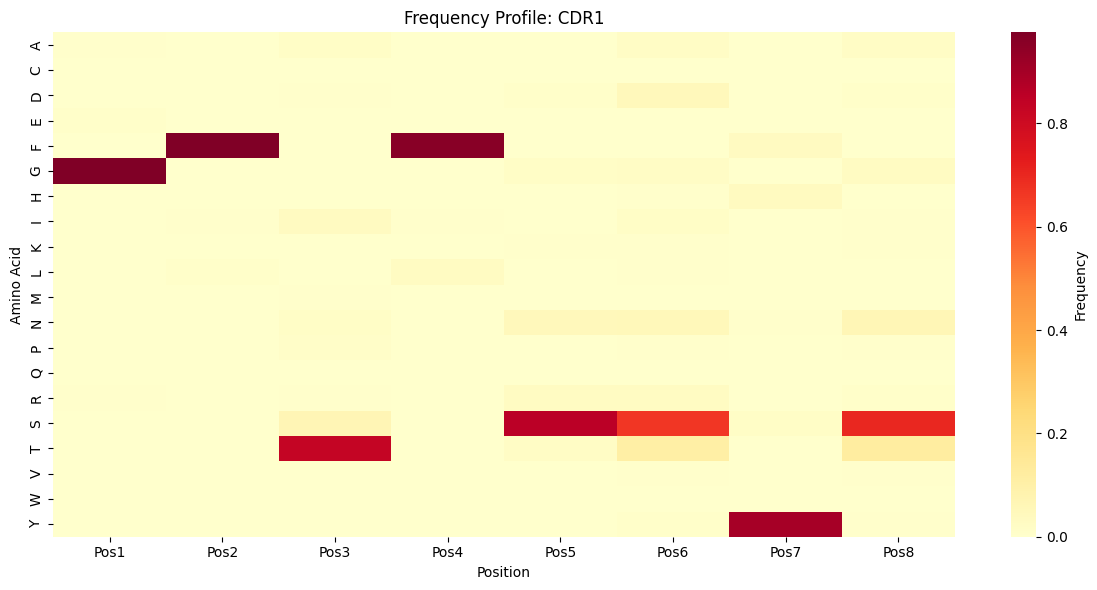

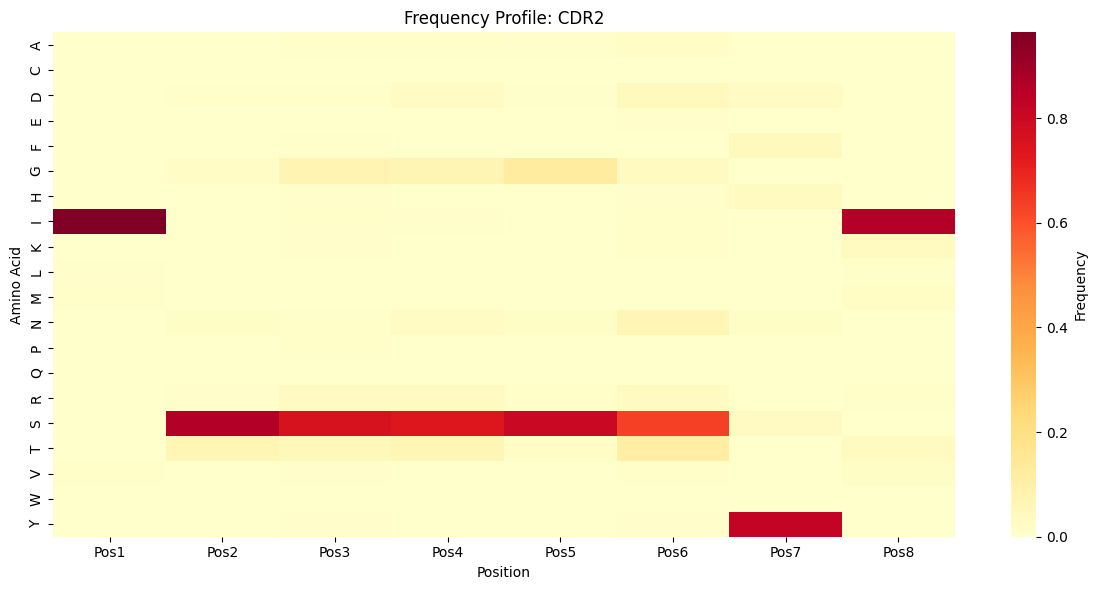

Профиль сохранен: cdr1_frequency_profile.csv
Профиль сохранен: cdr2_frequency_profile.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

df = pd.read_csv('ighv3-21_cdr_both_length8.csv')

def calculate_frequency_profile(sequences, region_name):
    if len(sequences) == 0:
        return None

    seq_length = len(sequences.iloc[0])

    frequency_matrix = []

    for position in range(seq_length):
        aa_at_position = sequences.str[position]
        aa_counts = Counter(aa_at_position)
        total = sum(aa_counts.values())

        aa_frequencies = {aa: count/total for aa, count in aa_counts.items()}

        frequency_matrix.append({
            'position': position + 1,
            'frequencies': aa_frequencies,
            'total': total,
            'top_aa': max(aa_frequencies.items(), key=lambda x: x[1])
        })

        sorted_aa = sorted(aa_frequencies.items(), key=lambda x: x[1], reverse=True)
        top3 = sorted_aa[:3]
        print(f"Позиция {position + 1:2d}: {', '.join([f'{aa}({freq:.1%})' for aa, freq in top3])}")

    return frequency_matrix

cdr1_sequences = df['cdr1_aa_heavy'].dropna()
cdr1_profile = calculate_frequency_profile(cdr1_sequences, "CDR1")

cdr2_sequences = df['cdr2_aa_heavy'].dropna()
cdr2_profile = calculate_frequency_profile(cdr2_sequences, "CDR2")

def plot_frequency_profiles(profile, title, filename):
    if not profile:
        return

    all_aa = set()
    for pos_data in profile:
        all_aa.update(pos_data['frequencies'].keys())
    all_aa = sorted(all_aa)

    freq_matrix = np.zeros((len(all_aa), len(profile)))

    for i, pos_data in enumerate(profile):
        for j, aa in enumerate(all_aa):
            freq_matrix[j, i] = pos_data['frequencies'].get(aa, 0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(freq_matrix,
                xticklabels=[f'Pos{i+1}' for i in range(len(profile))],
                yticklabels=all_aa,
                cmap='YlOrRd',
                cbar_kws={'label': 'Frequency'})
    plt.title(f'Frequency Profile: {title}')
    plt.xlabel('Position')
    plt.ylabel('Amino Acid')
    plt.tight_layout()
    plt.savefig(f'frequency_profile_{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

if cdr1_profile:
    plot_frequency_profiles(cdr1_profile, 'CDR1', 'cdr1')

if cdr2_profile:
    plot_frequency_profiles(cdr2_profile, 'CDR2', 'cdr2')

def save_profile_to_csv(profile, filename):
    rows = []
    for pos_data in profile:
        for aa, freq in pos_data['frequencies'].items():
            rows.append({
                'position': pos_data['position'],
                'amino_acid': aa,
                'frequency': freq,
                'count': int(freq * pos_data['total'])
            })

    profile_df = pd.DataFrame(rows)
    profile_df.to_csv(filename, index=False)
    print(f"Профиль сохранен: {filename}")

save_profile_to_csv(cdr1_profile, 'cdr1_frequency_profile.csv')
save_profile_to_csv(cdr2_profile, 'cdr2_frequency_profile.csv')